In [8]:
import matplotlib
matplotlib.use("Agg")  # Importante: no usamos ventana gráfica, solo guardamos el archivo

import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
import numpy as np

# --- Cargar los datos ---
# Breast Cancer: datos reales de tumores — 569 pacientes, 30 características por paciente
# y = 0 significa maligno (peligroso), y = 1 significa benigno (no peligroso)
cancer = load_breast_cancer()
X, y = cancer.data, cancer.target

# --- Dividir en entrenamiento y prueba ---
# 80% para entrenar, 20% para probar
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # Aprendemos la escala con los datos de entrenamiento
X_test_scaled = scaler.transform(X_test)        # Aplicamos la misma escala a los datos de prueba

# Probamos todos los valores de k entre 1 y 30
k_range = range(1, 31)
scores = []

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    # cv=10: dividimos los datos en 10 partes y probamos el modelo 10 veces
    cv_scores = cross_val_score(knn, X_train_scaled, y_train, cv=10)
    scores.append(np.mean(cv_scores))  # Guardamos el promedio de las 10 pruebas

# El k con la accuracy más alta es el mejor
best_k = k_range[np.argmax(scores)]
print(f'Bestes k: {best_k}, CV-Accuracy: {scores[np.argmax(scores)]:.3f}')

# --- Entrenar el modelo final con el mejor k ---
knn = KNeighborsClassifier(n_neighbors=best_k)
knn.fit(X_train_scaled, y_train)  # Entrenamos con todos los datos de entrenamiento

# --- Evaluar en los datos de prueba ---
y_pred = knn.predict(X_test_scaled)  # El modelo predice si cada tumor es maligno o benigno
print('Test-Accuracy:', np.mean(y_pred == y_test))  # Porcentaje de predicciones correctas

# Plot
plt.figure()
plt.plot(k_range, scores, marker='o')
plt.xlabel('k')           #
plt.ylabel('CV-Accuracy') # Eje vertical: qué tan bien funciona el modelo
plt.title('KNN: Wahl des besten k')
plt.grid(True)            # Líneas de fondo para leer mejor el gráfico
plt.tight_layout()
plt.savefig('knn_elbow.png', dpi=300)  # Guardamos el gráfico como imagen PNG
plt.close()


Bestes k: 7, CV-Accuracy: 0.971
Test-Accuracy: 0.9473684210526315


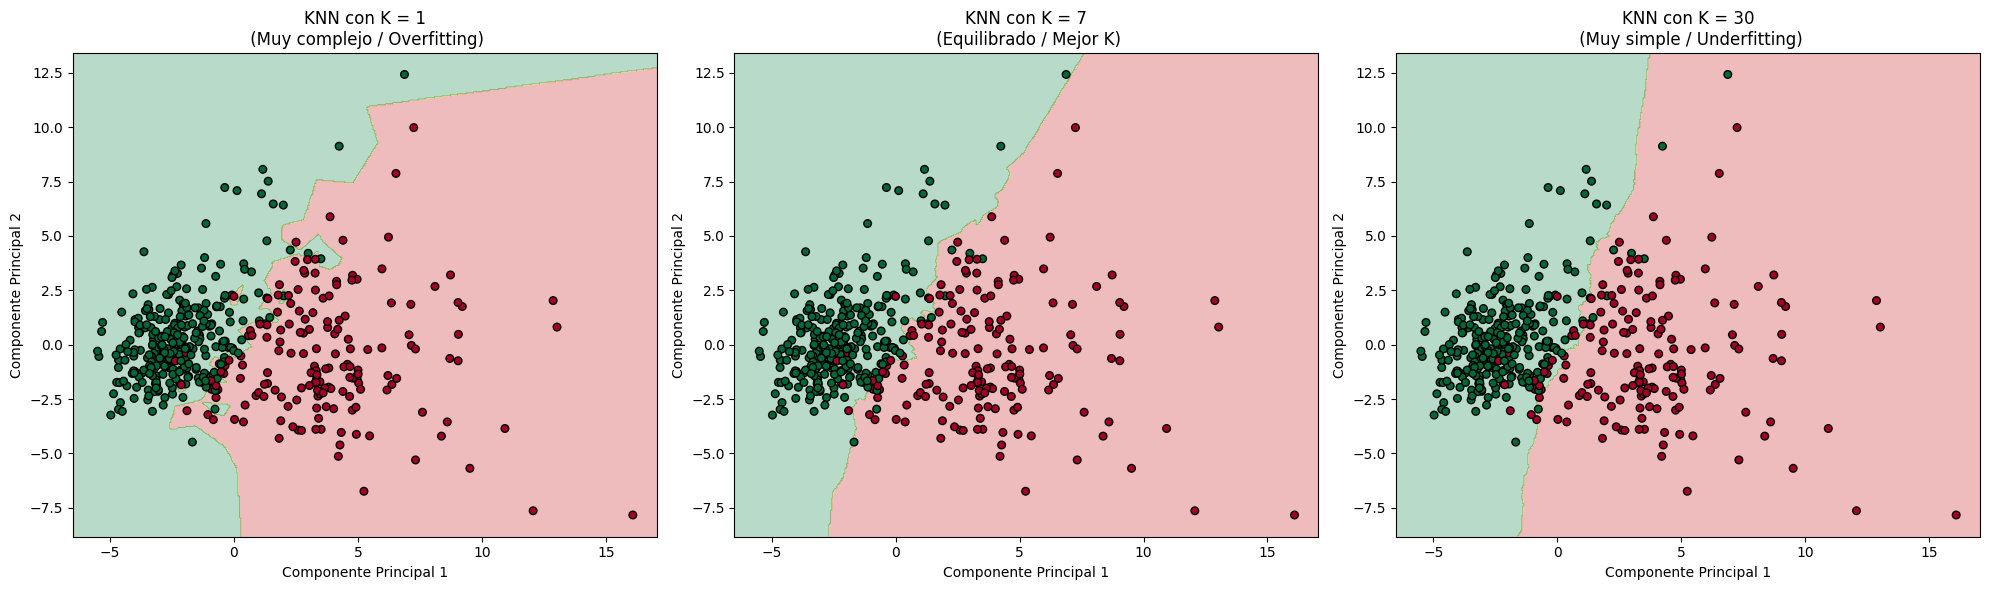

In [9]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.neighbors import KNeighborsClassifier
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Para que los gráficos se vean aquí mismo
%matplotlib inline

# 1. Simplificamos a 2 dimensiones para poder graficar (usando PCA)
pca = PCA(n_components=2)
X_train_2D = pca.fit_transform(X_train_scaled)

# 2. Definimos valores de K para comparar (uno bajo, el mejor encontrado, y uno alto)
ks_to_check = [1, best_k, 30]
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Crear una malla para pintar el fondo
h = .05
x_min, x_max = X_train_2D[:, 0].min() - 1, X_train_2D[:, 0].max() + 1
y_min, y_max = X_train_2D[:, 1].min() - 1, X_train_2D[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

for i, k in enumerate(ks_to_check):
    # Entrenar modelo con K específico
    knn_viz = KNeighborsClassifier(n_neighbors=k)
    knn_viz.fit(X_train_2D, y_train)

    # Predecir en toda la malla
    Z = knn_viz.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    # Dibujar las áreas de decisión
    axes[i].contourf(xx, yy, Z, alpha=0.3, cmap='RdYlGn')

    # Dibujar los puntos reales (Tumores)
    # Rojo = Maligno (0), Verde = Benigno (1)
    scatter = axes[i].scatter(X_train_2D[:, 0], X_train_2D[:, 1], c=y_train,
                              cmap='RdYlGn', edgecolor='k', s=30)

    axes[i].set_title(f'KNN con K = {k}\n' +
                      (' (Muy complejo / Overfitting)' if k==1 else
                       ' (Equilibrado / Mejor K)' if k==best_k else
                       ' (Muy simple / Underfitting)'))
    axes[i].set_xlabel('Componente Principal 1')
    axes[i].set_ylabel('Componente Principal 2')

plt.tight_layout()
plt.show()

### ¿Qué estamos viendo en estas gráficas?

*   **K=1 (Izquierda):** El modelo es muy 'nervioso'. Intenta rodear cada punto individualmente, creando fronteras muy irregulares. Esto suele ser **Overfitting** (aprende el ruido).
*   **K=Mejor (Centro):** Las fronteras son más suaves y lógicas. El modelo ignora puntos aislados que podrían ser errores y se enfoca en las tendencias generales.
*   **K=30 (Derecha):** El modelo se vuelve demasiado 'perezoso' o simple. Al promediar tantos vecinos, pierde detalles importantes de la forma de los datos (**Underfitting**).